# Πρόβλημα 3: **Belousov-Zhabotinsky**

## Βάλτε τα στοιχεία σας!

Πριν προχωρήσετε στην άσκηση συμπληρώστε το username και το password σας που σας έχει δοθεί και τρέξτε αυτό το κελί. Αυτές οι πληροφορίες είναι απαραίτητες για να σας αναγνωρίσει ο server και να βαθμολογήσει τις λύσεις σας.

- **Ο τελικός σας βαθμός καθορίζεται μόνο από το ΤΕΛΕΥΤΑΙΟ ΜΟΝΤΕΛΟ ΠΟΥ ΥΠΟΒΛΗΘΗΚΕ.**
- **Βεβαιωθείτε ότι χρησιμοποιείτε τα σωστά διαπιστευτήρια, διαφορετικά η λύση σας δεν θα βαθμολογηθεί.**

Εάν η ταυτοποίηση αποτύχει, θα δείτε ένα μήνυμα σφάλματος κάτω από την κλήση του `submit_for_grading()` στο τελευταίο κελί

In [ ]:
import requests
import os

SERVER_URL = "http://195.251.252.26:5000"

submission_data = {
    'username': 'contestant15',
    'password': 'dV3^m4FbX',
    'exercise': 'lab3_chemistry'
}

# The student must type the local name of this notebook file here if changed
NOTEBOOK_FILE = "/content/drive/MyDrive/Colab Notebooks/03_belousov_zhabotinsky.ipynb"
## NOTEBOOK_FILE = "03_belousov_zhabotinsky.ipynb"

FILE_CONFIG = {
    "lab3_chemistry": {
        "filename": "submission.npz",
        "mime": "application/octet-stream"
    }
}

## Περιγραφή

Η χημική αντίδραση Belousov-Zhabotinsky χρησιμοποιείται συνήθως για χημικές επιδείξεις αφού δημιουργεί εντυπωσιακά σχήματα. Όμως, ο μηχανισμός της είναι εξαιρετικά περίπλοκος. Σε αυτό το πρόβλημα θα υποθέσουμε ότι αντιδρούν 3 ενώσεις, οι A, B και C.

## Στόχος

Θα θέλαμε με βάση μια φωτογραφία του δοχείου της αντίδρασης να προβλέψουμε τις συγκεντρώσεις των ενώσεων Α, Β και C.

Όμως, η πρόβλεψη πρέπει να γίνει με ελάχιστη υπολογιστική ισχύ άρα θα πρέπει να εξάγετε λίγα features (δηλαδή χαρακτηριστικά της εικόνας) πριν χρησιμοποιήσετε ένα νευρωνικό δίκτυο.


## Δεδομένα

Για να πάρουμε τα δεδομένα κάναμε πειράματα αναμειγνύοντας ορισμένες ποσότητες από τις τρεις ενώσεις σε ένα κυκλικό ρηχό δοχείο με μαύρο πάτο.

Όμως, είχαμε μερικά προβλήματα:
- Κάποια στιγμή χάλασαν κάποιες λάμπες του εργαστηρίου με αποτέλεσμα κάποιες φωτογραφίες να είναι πιο σκοτεινές (δεν είναι όλες το ίδιο πιο σκοτεινές).
- Σε κάποιες φωτογραφίες το δεξί μισό της φωτογραφίας καταστράφηκε.

Δεν σημειώσαμε ποιες είχαν τα προβλήματα οπότε πρέπει να είστε προσεκτικοί πριν χρησιμοποιήσετε τις εικόνες.

Ο κώδικας για τη φόρτωση των δεδομένων εκπαίδευσης και για την αξιολόγηση στα δεδομένα test σας δίνεται.

### Μορφή Δεδομένων εκπαίδευσης

Για κάθε εικόνα εκπαίδευσης έχουμε τα παρακάτω δεδομένα:
- *$Q$*: Ένας αριθμός που αντιπροσωπεύει την αρχική κατάσταση του δοχείου.
- *$c_A, c_B, c_C$*: Οι συγκεντρώσεις των ενώσεων όταν βγάλαμε την φωτογραφία.

Οι εικόνες είναι `401x401` pixels.

### Μορφή Δεδομένων test

Στα δεδομένα test σας δίνεται μόνο η φωτογραφία και πρέπει να εξάγετε features.

## Πληροφορίες

+ Η ένωση Α είναι κόκκινη.
+ Η ένωση B είναι άχρωμη.
+ Η ένωση C είναι μπλε.
+ Μπορείτε να υποθέσετε ότι όταν αναμειγνύουμε δυο χρώματα, που σε rgb έχουν μόνο το ένα από τα 3 κανάλια, απλά προστίθενται.

# **Ξεκινήστε εδώ!**

[link text](https://(https:// [link text](https://)))## Βασικές βιβλιοθήκες και αρχικοποιήσεις

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from PIL import Image
import matplotlib.pyplot as plt

seed = 2026
np.random.seed(seed)
torch.manual_seed(seed)

### Φόρτωση δεδομένων εκπαίδευσης

In [ ]:
import gdown
import os
import zipfile

if not os.path.exists("/content/testA"):
  os.makedirs("/content/testA")
if not os.path.exists("/content/testB"):
  os.makedirs("/content/testB")
if not os.path.exists("/content/train"):
  os.makedirs("/content/train")

folder_id = '11kZqeXYgzdtrPJRp9ABH4yH0VFHRC3ha'
url = f'https://drive.google.com/drive/folders/{folder_id}?usp=sharing'
output_directory = '.'

if not os.path.exists(output_directory):
    os.makedirs(output_directory)
gdown.download_folder(url, output=output_directory, quiet=False, remaining_ok=True)
print(f"Successfully downloaded data to {output_directory}")

zip_path = '/content/testA/images.zip'
extract_path = '/content/testA'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print(f"Extraction complete to {extract_path}")

zip_path = '/content/testB/images.zip'
extract_path = '/content/testB'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print(f"Extraction complete to {extract_path}")

zip_path = '/content/train/images.zip'
extract_path = '/content/train'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print(f"Extraction complete to {extract_path}")

Retrieving folder contents


Retrieving folder 17bIFDc4oAp03pSEOU7KLwcGvx4N-o2hX testA
Processing file 1LLny4vkmNvNMN5CuG8Qr71itBDesjDiv images.zip
Retrieving folder 1V3yGK4rN2bT99V7e_B7SRUNO6ZzaK6pp testB
Processing file 1Z0vaCBwB6JMNWDaFJGsJct7F1F-Krjag images.zip
Retrieving folder 1UZCJuVrSb3hFX1M7Li5R_FKF-q67nLMs train
Processing file 1Vqtz6ML6H3mWWNKQNPilGLjtvwnAkZLp data.csv
Processing file 1XJZYGtZXZd1EWykuS6OZfUgmrbFDQsxg images.zip


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1LLny4vkmNvNMN5CuG8Qr71itBDesjDiv
From (redirected): https://drive.google.com/uc?id=1LLny4vkmNvNMN5CuG8Qr71itBDesjDiv&confirm=t&uuid=189d2220-95ca-4e13-a852-7b0d2238ee2e
To: /content/testA/images.zip
100%|██████████| 27.0M/27.0M [00:00<00:00, 185MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1Z0vaCBwB6JMNWDaFJGsJct7F1F-Krjag
From (redirected): https://drive.google.com/uc?id=1Z0vaCBwB6JMNWDaFJGsJct7F1F-Krjag&confirm=t&uuid=dfe5efa4-17a2-43a4-a175-521c1e82d273
To: /content/testB/images.zip
100%|██████████| 36.7M/36.7M [00:00<00:00, 195MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Vqtz6ML6H3mWWNKQNPilGLjtvwnAkZLp
To: /content/train/data.csv
100%|██████████| 20.8k/20.8k [00:00<00:00, 33.0MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1XJZYGtZXZd1EWykuS6OZfUgmrbFDQsxg
F

Successfully downloaded data to .
Extraction complete to /content/testA
Extraction complete to /content/testB
Extraction complete to /content/train


In [ ]:
df = pd.read_csv("./train/data.csv")
N = len(df)
df

,Q,c_A,c_B,c_C
0,11.147116,2.936832,9.751760,0.888632
1,11.147116,1.341728,10.722040,2.509808
2,11.147116,1.391792,13.804920,1.405184
3,11.147116,1.830400,12.582740,1.282768
4,11.419561,1.121136,14.363675,1.652072
...,...,...,...,...
555,12.585409,1.089216,14.551031,2.584312
556,11.427459,5.721440,2.463192,2.241440
557,11.427459,3.518912,8.087880,0.987072
558,11.427459,4.581280,1.520952,3.596128


[[255 255 255]
 [255 255 255]
 [255 255 255]
 [255 255 255]
 [162 162 162]
 [172 172 172]
 [164 164 164]
 [139 139 139]
 [255 255 255]
 [255 255 255]
 [255 255 255]
 [255 255 255]
 [255 255 255]
 [255 255 255]
 [255 255 255]
 [255 255 255]
 [179 179 179]
 [169 169 169]
 [117 117 117]
 [ 94  94  94]
 [168 168 168]
 [188 188 188]
 [135 135 135]
 [198 198 198]
 [199 199 199]
 [166 166 166]
 [114 114 114]
 [117 117 117]
 [196 196 196]
 [174 174 174]
 [161 161 161]
 [113 113 113]
 [255 255 255]
 [255 255 255]
 [255 255 255]
 [255 255 255]
 [255 255 255]
 [255 255 255]
 [255 255 255]
 [255 255 255]
 [255 255 255]
 [255 255 255]
 [255 255 255]
 [255 255 255]
 [160 160 160]
 [178 178 178]
 [198 198 198]
 [186 186 186]
 [168 168 168]
 [165 165 165]
 [200 200 200]
 [106 106 106]
 [255 255 255]
 [255 255 255]
 [255 255 255]
 [255 255 255]
 [255 255 255]
 [255 255 255]
 [255 255 255]
 [255 255 255]
 [255 255 255]
 [255 255 255]
 [255 255 255]
 [255 255 255]
 [255 255 255]
 [255 255 255]
 [255 255 

array([[[ 92, 137,   2],
        [ 92, 137,   2],
        [ 92, 137,   2],
        ...,
        [255, 127,   0],
        [254,  61, 153],
        [246, 114,  74]],

       [[ 92, 137,   2],
        [ 92, 137,   2],
        [ 92, 137,   2],
        ...,
        [255, 196,  10],
        [229,  34,   0],
        [254, 139,  25]],

       [[ 92, 137,   2],
        [ 92, 137,   2],
        [ 92, 137,   2],
        ...,
        [200, 139,  95],
        [255, 114,  35],
        [255,  90,  50]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [143,  95,   5],
        [255, 112, 144],
        [255, 168,  81]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [233, 127,  89],
        [255, 173,  34],
        [255, 129,   1]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [253, 187,  18],
        [241, 154,   0],
        [255, 215,   0]]], dtype=uint8)
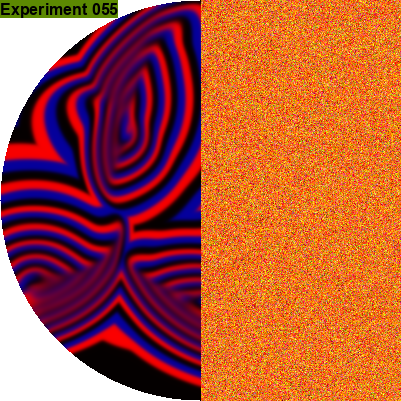

In [ ]:
imgs = np.array([np.array(Image.open(f"./train/images/{idx}.png")) for idx in range(100, 200)])
imgs2 = np.array([Image.open(f"./train/images/{idx}.png") for idx in range(100, 200)])
mask = imgs[:, 0, 0, :] < 255
print(imgs[:, 400, 50, :])
# imgs2 = imgs2[mask]
sums1 = 0
print(imgs2.shape)
imgs2[-1]

Q      12.090165
c_A     1.322640
c_B    10.385480
c_C     3.476936
Name: 41, dtype: float64
[[0.01176471 0.         0.42745098]
 [0.00784314 0.         0.43529412]
 [0.00392157 0.         0.44313725]
 ...
 [1.         0.         0.24705882]
 [0.84313725 0.         0.23529412]
 [0.75686275 0.         0.10588235]]


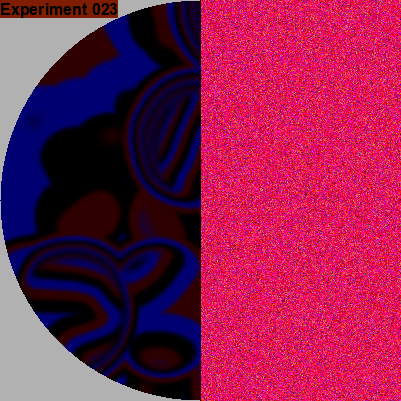

In [ ]:
idx = 41
print(df.iloc[idx])
image = Image.open(f"./train/images/{idx}.png")
rgb = np.array(image) / 255
print(rgb[200, :])
image

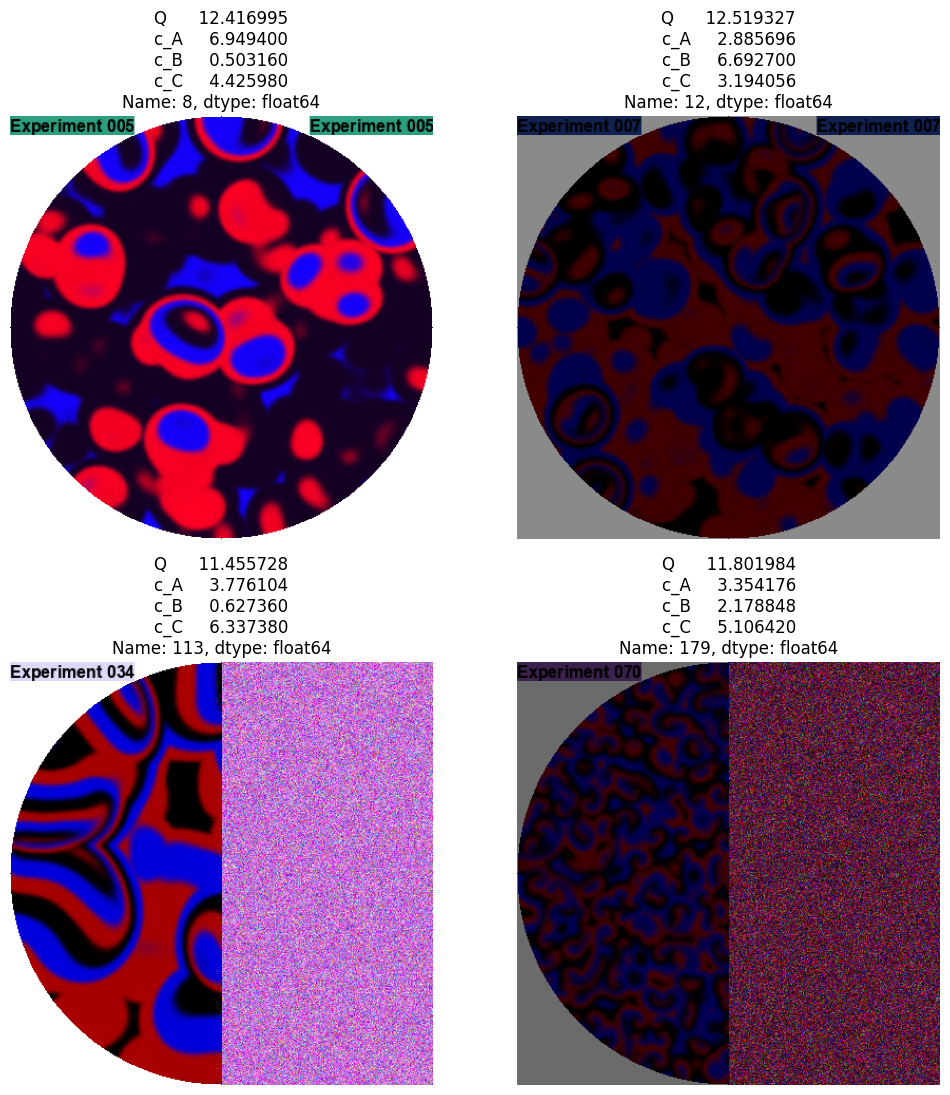

In [ ]:
idxs = [8,12,113,179]
fig, axs = plt.subplots(2, 2, figsize=(12, 13))
for i, ax in enumerate(axs.flat):
	ax.axis('off')
	ax.set_title(f"{df.iloc[idxs[i]]}")
	ax.imshow(Image.open(f"./train/images/{idxs[i]}.png"))


## Εκπαίδευση

##### 1. Εξαγωγή features

In [ ]:
def create_features(image):
	rgb = np.array(image) / 255

	# TODO: Eξάγετε features
    # π.χ
	return [rgb[0,0,0],rgb[100,100,2]]

NUM_FEATURES = len(create_features(Image.open(f"./train/images/0.png")))

##### 2. Προετοιμασία δεδομένων

In [ ]:
images_features = np.zeros((N, NUM_FEATURES), dtype=np.float32)
for i in range(N):
	images_features[i] = create_features(Image.open(f"./train/images/{i}.png"))

Q_col = df["Q"].to_numpy().reshape(-1, 1)
inputs = np.concatenate((Q_col, images_features), axis=1)
targets = df[["c_A", "c_B", "c_C"]].to_numpy()

dataset = TensorDataset(torch.tensor(inputs, dtype=torch.float32), torch.tensor(targets, dtype=torch.float32))

##### 3. Εκπαίδευση νευρωνικού

In [ ]:
# Μπορείτε να το τροποποιήσετε αλλά προσέξτε τις προϋποθέσεις. Μην χρησιμοποιήσετε class αλλά χρησιμοποιήστε το nn.Sequential
model = nn.Sequential(
	nn.Linear(1 + NUM_FEATURES,16),
	nn.ReLU(),
	nn.LayerNorm(16),
	nn.Linear(16,16),
	nn.ReLU(),
	nn.Linear(16,32),
	nn.ReLU(),
	nn.Linear(32,3)
)

In [ ]:
print(f"Using {sum(p.numel() for p in model.parameters())} paramenters")

Using 1011 paramenters


In [ ]:
import torch
import copy
import torch.nn.functional as F
import matplotlib as plt

def train(model, train_loader, optimizer, epochs, criterion):
  device = "cpu"
  train_losses = []
  test_losses = []
  test_accuracies = []

  best_accuracy = 0
  best_model_wts = copy.deepcopy(model.state_dict())

  for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch_x, batch_y in train_loader:
      optimizer.zero_grad()
      outputs = model(batch_x)
      loss = criterion(outputs, batch_y)
      loss.backward()
      optimizer.step()
      total_loss += loss.item()
    train_losses.append(total_loss / len(train_loader))

    model.eval()
    total_test_loss = 0
    correct = 0
    total = 0

    # with torch.no_grad():
    #   for batch_x, batch_y in test_loader:
    #     outputs = model(batch_x)
    #     loss = criterion(outputs, batch_y)
    #     total_test_loss += loss.item()

    #     _, predicted = torch.max(outputs.data, 1)
    #     total += batch_y.size(0)
    #     correct += (predicted == batch_y).sum().item()

    # epoch_loss = total_test_loss / len(test_loader)
    # epoch_accuracy = correct / total
    # test_losses.append(epoch_loss)
    # test_accuracies.append(epoch_accuracy)

    # if epoch_accuracy > best_accuracy:
    #   best_accuracy = epoch_accuracy
    #   best_model_wts = copy.deepcopy(model.state_dict())
    #   best_epoch = epoch + 1

    print(
        f"epoch {epoch+1}/{epochs} "
        f"training loss: {train_losses[-1]}"
        # f"Testing Loss: {test_losses[-1]}"
        # f"Testing Accuracy: {epoch_accuracy:.4f}"
    )
    # model.load_state_dict(best_model_wts)
    # print(f"best epoch: {best_epoch} test acc: {best_accuracy}")


In [ ]:
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch

criterion = nn.MSELoss()
dataloader = DataLoader(dataset, batch_size=32)
opimizer = torch.optim.Adam(model.parameters())
train(model, dataloader, opimizer, 200, criterion)

epoch 1/200 training loss: 26.902885648939346
epoch 2/200 training loss: 25.13055419921875
epoch 3/200 training loss: 23.527409235636394
epoch 4/200 training loss: 20.70463254716661
epoch 5/200 training loss: 16.08488506740994
epoch 6/200 training loss: 11.729946057001749
epoch 7/200 training loss: 9.53984687063429
epoch 8/200 training loss: 8.487662315368652
epoch 9/200 training loss: 8.261545552147759
epoch 10/200 training loss: 8.252376980251736
epoch 11/200 training loss: 8.249136765797934
epoch 12/200 training loss: 8.248317692014906
epoch 13/200 training loss: 8.248289002312553
epoch 14/200 training loss: 8.24826521343655
epoch 15/200 training loss: 8.248150851991442
epoch 16/200 training loss: 8.247991508907742
epoch 17/200 training loss: 8.247823264863756
epoch 18/200 training loss: 8.247635205586752
epoch 19/200 training loss: 8.247425900565254
epoch 20/200 training loss: 8.247192912631565
epoch 21/200 training loss: 8.2469375928243
epoch 22/200 training loss: 8.24665731853909

## Υποβολή

Θα υποβάλετε την αρχιτεκτονική και τα βάρη του νευρωνικού σας μαζί με τα features των εικόνων test. To μοντέλο σας θα τρέξει όταν το υποβάλετε. Το πρώτο επίπεδο θα πρέπει να παίρνει $1 + a$ features όπου:
- το πρώτο θα προστεθεί από τον server όταν θα κάνετε την υποβολή και είναι το $Q$
- τα άλλα $a$ θα είναι αυτά που έχετε εξάγει και υποβάλει για τις εικόνες.
Το τελευταίο επίπεδο πρέπει να παράγει 3 αριθμούς που να είναι οι συγκεντρώσεις των Α, Β και C σε αυτήν την σειρά

Το νευρωνικό δίκτυο που θα φτιάξετε πρέπει:
- να έχει μέχρι $2000$ παραμέτρους
- να αποτελείται μόνο από επίπεδα `Linear`, `LayerNorm`, `ReLU`, `ELU`, `Mish` ή `Tanh`
- Το πρώτο επίπεδο πρέπει να είναι `Linear`

Αν δεν πληροί τις παραπάνω προϋποθέσεις θα βαθμολογηθείτε με 0

## Βαθμολόγηση

Υπό την προϋπόθεση ότι το μοντέλο σας πληροί τα κριτήρια που περιγράφονται παραπάνω, η υποβολή σας βαθμολογείται όπως παρακάτω:

Αρχικά, υπολογίζεται για κάθε εικόνα το $\text{Score}_i$:

$$
\text{Score}_i = \frac{1}{3} \sum_{k \in \{A,B,C\}} \max\left(0, 1 - \frac{5|c_k - \hat{c}_k|}{\sqrt{c_k} + 1}\right)
$$

όπου:
* $c_k$: η πραγματική συγκέντρωση της ένωσης $k$
* $\hat{c}_k$: η συγκέντρωση της ένωσης $k$ που προβλέψατε

Για τον υπολογισμό της βαθμολογίας, αθροίζονται τα score και πολλαπλασιάζονται με έναν συντελεστή ανάλογα πόσα features χρησιμοποιείτε για κάθε εικόνα, με βάση το πόσα inputs παίρνει το πρώτο επίπεδο του μοντέλου σας (π.χ. αν το πρώτο επίπεδο παίρνει 7 inputs τότε χρησιμοποιείτε $a=7-1=6$ features).

$$
\text{Score} = \frac{\mu(a)}{N} \sum_{i=0}^N \text{Score}_i
$$

$$
\mu(a) = \begin{cases}
1 & 0 \leq a \leq 2 \\
-\frac{1}{10}(a-2) + 1 & 2 < a \leq 4 \\
-\frac{1}{100}(a-4) + 0.8 & 4 < a \leq 20 \\
-\frac{1}{400}(a-20) + 0.64 & 20 < a \leq 276 \\
0 & a > 276
\end{cases}
$$

Θα βαθμολογηθείτε στο testA και στο testB. Το score του testA θα σας δοθεί αλλά **μόνο το κρυφό score του testB θα μετρήσει τελικά!**

Οι πόντοι που παίρνετε είναι ίσοι με $\min(100, 110 * \text{Score})$

## Υπολογισμός της Λύσης

In [ ]:
#########################################
####    DO NOT CHANGE THIS CELL      ####
#########################################

import json

# Εξαγωγή test features
test_featuresA = np.zeros((160, NUM_FEATURES), dtype=np.float32)
for i in range(160):
	test_featuresA[i] = create_features(Image.open(f"./testA/images/{i}.png"))

test_featuresB = np.zeros((240, NUM_FEATURES), dtype=np.float32)
for i in range(240):
	test_featuresB[i] = create_features(Image.open(f"./testB/images/{i}.png"))

def get_architecture(model):
    layers = []
    for name, layer in model.named_children():
        if isinstance(layer, nn.Linear):
            layers.append({
                "type": "Linear",
                "in_features": layer.in_features,
                "out_features": layer.out_features
            })
        elif isinstance(layer, nn.LayerNorm):
            layers.append({
                "type": "LayerNorm",
                "normalized_shape": layer.normalized_shape[0]
            })
        elif isinstance(layer, nn.ReLU):
            layers.append({
                "type": "ReLU"
            })
        elif isinstance(layer, nn.ELU):
            layers.append({
                "type": "ELU"
            })
        elif isinstance(layer, nn.Mish):
            layers.append({
                "type": "Mish"
            })
        elif isinstance(layer, nn.Tanh):
            layers.append({
                "type": "Tanh"
            })
        else:
            print(f"[!] Χρησιμοποιείτε layer {layer.__class__.__name__} που δεν επιτρέπεται!")
            return None

    if(layers[0]["type"] != "Linear"):
        print(f"[!] Το πρώτο layer δεν είναι Linear! (Είναι {layer.__class__.__name__})")
        return None

    num_params = sum(p.numel() for p in model.parameters())
    if num_params > 2000:
        print(f"[!] Χρησιμοποιείτε πολλά parameters! {num_params} > 2000")
        return None

    return layers

layers = get_architecture(model)
if layers is None:
    print("[!] Η υποβολή δεν θα αξιολογηθεί γιατί δεν πληροί τα κριτήρια!")
    raise ValueError("Invalid layers")

def mu(a):
    if 0 <= a <= 2: return 1.0
    elif 2 < a <= 4: return -0.1 * (a - 2) + 1
    elif 4 < a <= 20: return -0.01 * (a - 4) + 0.8
    elif 20 < a <= 276: return -0.0025 * (a - 20) + 0.64
    else: return 0.0
param_a = layers[0]["in_features"] - 1

if param_a != NUM_FEATURES:
    print("[!] Αναντιστοιχία στον αριθμό των features που παράγονται και στο input του πρώτου layer!")
    raise ValueError("Not matching number of features")

print(f"Χρησιμοποιείτε {param_a} features άρα θα έχετε συντελεστή {mu(param_a)}")

submission = {
    "architecture_json": json.dumps(layers),
    "featuresA": test_featuresA,
    "featuresB": test_featuresB,
    **{
        f"state::{k}": v.detach().cpu().numpy() for k, v in model.state_dict().items()
    }
}

np.savez_compressed("submission.npz", **submission, allow_pickle=False)

Χρησιμοποιείτε 2 features άρα θα έχετε συντελεστή 1.0


## Υποβολή της Λύσης στο Σύστημα Αξιολόγησης

In [ ]:
#########################################
####    DO NOT CHANGE THIS CELL      ####
#########################################
from google.colab import drive
drive.mount('/content/drive')

def submit_for_grading():
    """Submits the generated predictions/weights for automated grading."""
    username = submission_data.get('username')
    exercise = submission_data.get('exercise')
    output_file = f"{username}_{exercise}_final_score.csv"
    endpoint = f"{SERVER_URL}/grade"

    config = FILE_CONFIG.get(exercise)
    if not config:
        print(f" Error: Unknown exercise '{exercise}'.")
        return

    input_file = config["filename"]
    mime_type = config["mime"]

    if not os.path.exists(input_file):
        print(f" Error: Could not find '{input_file}'. Have you generated your submission file yet?")
        return

    print(f"Connecting to {endpoint}...")
    print(f"Submitting {input_file} for {exercise}...")

    try:
        with open(input_file, 'rb') as f:
            files = {'file': (input_file, f, mime_type)}
            response = requests.post(endpoint, files=files, data=submission_data)

        if response.status_code == 200:
            with open(output_file, 'wb') as f_out:
                f_out.write(response.content)
            print(f" Grading Success! Your score report has been saved to '{output_file}'.")
        else:
            print_server_error(response)

    except requests.exceptions.ConnectionError:
        print(" Failed to connect to the grading server. Check your network or VPN.")


def submit_notebook():
    """Uploads the Jupyter Notebook to the grading server."""
    endpoint = f"{SERVER_URL}/submit_notebook"

    if not os.path.exists(NOTEBOOK_FILE):
        print(f" Error: Could not find notebook '{NOTEBOOK_FILE}'. Check the filename.")
        return

    print(f"\nArchiving notebook {NOTEBOOK_FILE} to the server...")

    try:
        with open(NOTEBOOK_FILE, 'rb') as f:
            files = {'file': (NOTEBOOK_FILE, f, 'application/x-ipynb+json')}
            response = requests.post(endpoint, files=files, data=submission_data)

        if response.status_code == 200:
            print(f" Notebook successfully archived on the server!")
        else:
            print_server_error(response)

    except requests.exceptions.ConnectionError:
        print(" Failed to connect to the server. Check your network or VPN.")


def print_server_error(response):
    """Helper function to parse and display server errors cleanly."""
    try:
        error_data = response.json()
        print(f"\n SERVER ERROR {response.status_code} ")
        print(f"Summary: {error_data.get('error', 'Unknown Error')}")
        if 'details' in error_data:
            print(f"Details:\n{error_data['details']}")
    except:
        print(f"\n Server Error {response.status_code}: {response.text}")


# 1. Submit the predictions for an automated score
submit_for_grading()

# 2. Upload the notebook code to the TA archive
submit_notebook()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Connecting to http://195.251.252.26:5000/grade...
Submitting submission.npz for lab3_chemistry...
 Grading Success! Your score report has been saved to 'contestant15_lab3_chemistry_final_score.csv'.

Archiving notebook /content/drive/MyDrive/Colab Notebooks/03_belousov_zhabotinsky.ipynb to the server...
 Notebook successfully archived on the server!
